Import bibiotek

In [2]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
import numpy as np
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import learning_curve
import matplotlib.pyplot as plt
from sklearn.model_selection import GridSearchCV

Ładowanie danych

In [3]:
X_train=pd.read_csv('Dataset_4f_time_only/X_train.csv')
Y_train=pd.read_csv('Dataset_4f_time_only/Y_train.csv')
X_test=pd.read_csv('Dataset_4f_time_only/X_test.csv')
Y_test=pd.read_csv('Dataset_4f_time_only/Y_test.csv')

Przerabiane danych i model

In [10]:
Y_train_d=np.ravel(Y_train)
Y_test_d=np.ravel(Y_test)
class_names = [f"cluster_{i}" for i in np.unique(Y_train_d)]
feature_names = X_train.columns.tolist()

# istnienie modelu
model=RandomForestClassifier(
    n_estimators=2000,
    max_features=0.5,
    criterion='gini',
    min_samples_leaf=1,
    class_weight='balanced',
    random_state=230,
    max_depth=None,
    n_jobs=-1
)
model.fit(X_train, Y_train_d)
print(f'Trening zakończono')

Trening zakończono


Analiza modelu

              precision    recall  f1-score   support

           0       0.70      0.64      0.67        73
           1       0.49      0.55      0.52        75
           2       0.81      0.87      0.84       144
           3       0.32      0.22      0.26        41

    accuracy                           0.67       333
   macro avg       0.58      0.57      0.57       333
weighted avg       0.65      0.67      0.66       333

Cross Validation be like: 0.650 +- 0.020


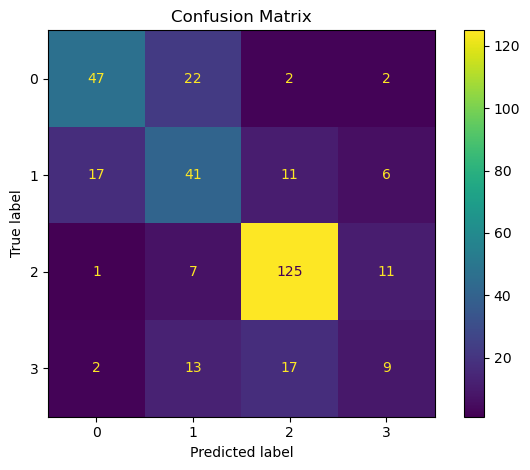

In [11]:
y_pred=model.predict(X_test)
print(classification_report(Y_test_d,y_pred))

cv_results = cross_val_score(model, X_train, Y_train_d, cv=5)
print(f'Cross Validation be like: {cv_results.mean():.3f} +- {cv_results.std():.3f}')

ConfusionMatrixDisplay.from_estimator(
    model, X_test, Y_test_d
)
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

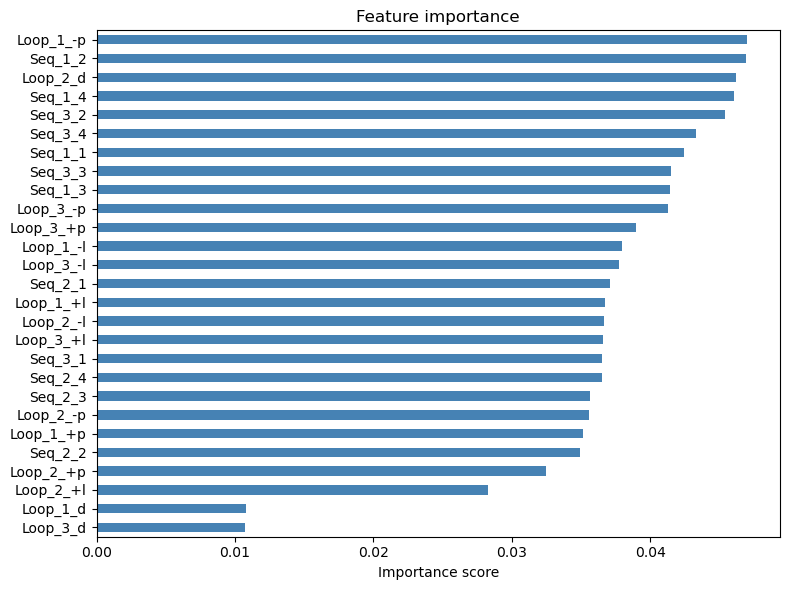

In [6]:
importances = pd.Series(model.feature_importances_, index=feature_names)
importances.sort_values().plot(kind="barh", figsize=(8, 6), color="steelblue")
plt.title("Feature importance")
plt.xlabel("Importance score")
plt.tight_layout()
plt.show()

In [ ]:
n_trees_range = [10, 50, 100, 150, 200, 300, 400, 500, 700, 1000, 1200, 1500, 2000, 3000 ]
scores = []

for n in n_trees_range:
    rf = RandomForestClassifier(n_estimators=n,
    max_features=0.5,
    criterion='gini',
    min_samples_leaf=1,
    class_weight='balanced',
    random_state=42,
    max_depth=None,
    n_jobs=-1)
    score = cross_val_score(rf, X_train, Y_train, cv=3).mean()
    scores.append(score)

plt.plot(n_trees_range, scores, marker="o", color="steelblue")
plt.xlabel("Number of trees")
plt.ylabel("CV accuracy")
plt.title("Accuracy vs number of trees")
plt.grid(True, alpha=0.3)
plt.show()

In [4]:
report = classification_report(Y_test, y_pred,
                               target_names=class_names,
                               output_dict=True)

f1_scores = {cls: report[cls]["f1-score"] for cls in class_names}
pd.Series(f1_scores).sort_values().plot(kind="barh", color="steelblue", figsize=(7, 4))
plt.xlabel("F1 score")
plt.title("Per-class F1 score")
plt.axvline(x=0.8, color="red", linestyle="--", alpha=0.5, label="0.8 threshold")
plt.legend()
plt.tight_layout()
plt.show()

NameError: name 'y_pred' is not defined

In [ ]:
param_grid = {
    "n_estimators":     [200, 400, 600,400, 500, 700, 1000, 1200],
    "max_depth":        [None, 10, 20, 30],
    "min_samples_leaf": [1, 2, 4],
    "criterion": ["gini", "entropy"],
    "max_features":     ["sqrt", "log2", 0.5]
}

grid = GridSearchCV(
    RandomForestClassifier(class_weight="balanced", random_state=42, n_jobs=-1),
    param_grid,
    cv=5,
    scoring="f1_macro",   # macro F1 is better than accuracy for imbalanced classes
    n_jobs=-1
)
grid.fit(X_train, Y_train)

print("Best params:", grid.best_params_)
print("Best score:", grid.best_score_)
model = grid.best_estimator_

Learning curve - idk what a i doing

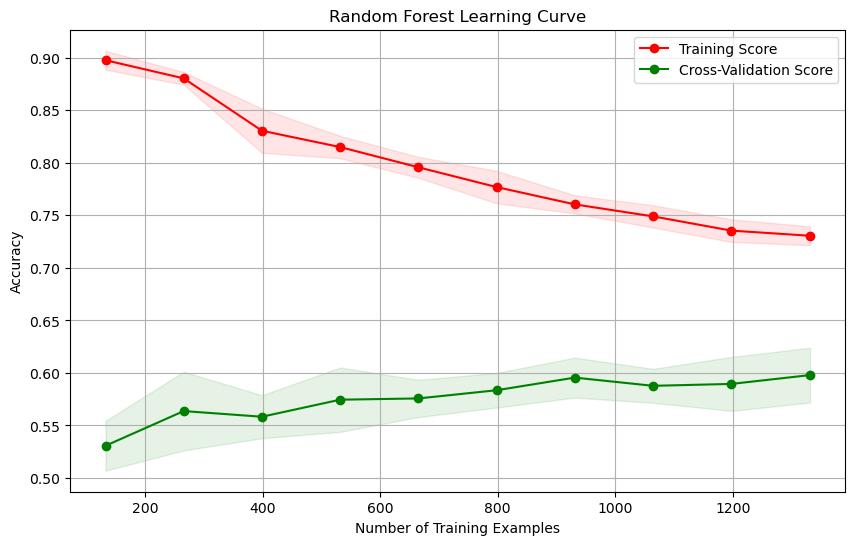

In [5]:
# 1. Load Data
X=pd.concat([X_train, X_test], axis=0, ignore_index=True)
Y=pd.concat([Y_train, Y_test], axis=0, ignore_index=True)
Y=np.ravel(Y)
# 2. Define the Random Forest Model
# Key parameters to tune if you see overfitting: max_depth, min_samples_leaf
model = RandomForestClassifier(
    n_estimators=2000,
    max_features=1,
    criterion='gini',
    min_samples_leaf=2,
    class_weight='balanced',
    random_state=230,
    max_depth=5,
    n_jobs=-1
)

# 3. Generate Learning Curve Data
train_sizes, train_scores, test_scores = learning_curve(
    model, X, Y, cv=5, scoring='accuracy', n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 10)
)

# 4. Calculate Mean and Standard Deviation
train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

# 5. Plot the Curve
plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_mean, label="Training Score", color="red", marker='o')
plt.plot(train_sizes, test_mean, label="Cross-Validation Score", color="green", marker='o')

# Add variance bands
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, color="red", alpha=0.1)
plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, color="green", alpha=0.1)

plt.title("Random Forest Learning Curve")
plt.xlabel("Number of Training Examples")
plt.ylabel("Accuracy")
plt.legend(loc="best")
plt.grid(True)
plt.show()

In [17]:
print(X)

      Loop_1_-p  Loop_1_+p  Loop_1_-l  Loop_1_+l  Loop_1_d  Loop_2_-p  \
0           0.0        0.0        1.0        0.0       0.0        0.0   
1           0.0        1.0        0.0        0.0       0.0        0.0   
2           0.0        0.0        1.0        0.0       0.0        0.0   
3           1.0        0.0        0.0        0.0       0.0        1.0   
4           0.0        0.0        1.0        0.0       0.0        0.0   
...         ...        ...        ...        ...       ...        ...   
1659        0.0        1.0        0.0        0.0       0.0        0.0   
1660        0.0        1.0        0.0        0.0       0.0        0.0   
1661        0.0        1.0        0.0        0.0       0.0        0.0   
1662        0.0        0.0        0.0        1.0       0.0        0.0   
1663        0.0        0.0        0.0        1.0       0.0        0.0   

      Loop_2_+p  Loop_2_-l  Loop_2_+l  Loop_2_d  ...  Seq_1_3  Seq_1_4  \
0           0.0        0.0        0.0       1.0  